(13)=
# Chapter 13: Statistics & Random Sampling & Distributions

**Topics Covered:**
- Descriptive statistics: mean, median, variance, standard deviation, percentiles
- Random number generation with `numpy.random`
- Key probability distributions: uniform, normal, exponential, Poisson
- The Central Limit Theorem and why it matters in engineering
- Monte Carlo simulation: error propagation and process reliability
- Confidence intervals and hypothesis testing basics

In [3]:
# ── All imports ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

(13.1)=
## 13.1 Motivation: Why Statistics in Chemical Engineering?

Real engineering data is **never perfect**. Thermocouples drift. Flow meters have noise. Reaction yields vary batch to batch. Laboratory measurements have inherent uncertainty.

Statistics gives us the tools to:
- **Summarize** a dataset — what is the typical value? how spread out are the measurements?
- **Quantify uncertainty** — how confident are we in a measured mean?
- **Propagate errors** — if each input has uncertainty, what is the uncertainty in the output?
- **Test hypotheses** — is the new catalyst actually better, or did we just get lucky?
- **Simulate variability** — what fraction of batches will fail quality specs?

Consider a batch reactor producing a pharmaceutical intermediate. The target yield is 88%. You run 15 batches and get:

```
85.2, 87.9, 90.1, 86.3, 88.7, 84.5, 89.3, 87.1,
91.0, 85.8, 88.2, 86.7, 89.5, 87.4, 88.0
```

Questions you need to answer:
- What is the average yield, and how much does it vary?
- Is the process meeting the 88% target on average?
- What fraction of future batches will fall below the 85% lower limit?
- How many measurements do you need to estimate the mean within ±0.5%?

All of these require statistics.

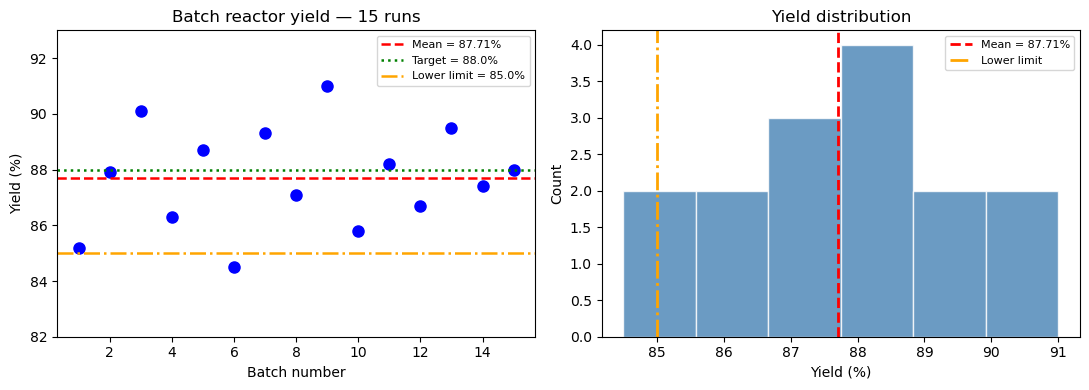

Number of batches  : 15
Mean yield         : 87.71%
Batches below 85%  : 1


In [4]:
# Batch reactor yield data (% yield)
yields = np.array([85.2, 87.9, 90.1, 86.3, 88.7, 84.5, 89.3, 87.1,
                   91.0, 85.8, 88.2, 86.7, 89.5, 87.4, 88.0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: raw data as a dot plot
ax = axes[0]
ax.plot(range(1, len(yields)+1), yields, 'bo', markersize=8)
ax.axhline(np.mean(yields), color='red',    linestyle='--', linewidth=1.8, label=f'Mean = {np.mean(yields):.2f}%')
ax.axhline(88.0,             color='green', linestyle=':',  linewidth=1.8, label='Target = 88.0%')
ax.axhline(85.0,             color='orange',linestyle='-.',  linewidth=1.8, label='Lower limit = 85.0%')
ax.set_xlabel('Batch number')
ax.set_ylabel('Yield (%)')
ax.set_title('Batch reactor yield — 15 runs')
ax.legend(fontsize=8)
ax.set_ylim(82, 93)

# Right: histogram
ax = axes[1]
ax.hist(yields, bins=6, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(yields), color='red',    linestyle='--', linewidth=2, label=f'Mean = {np.mean(yields):.2f}%')
ax.axvline(85.0,             color='orange', linestyle='-.', linewidth=2, label='Lower limit')
ax.set_xlabel('Yield (%)')
ax.set_ylabel('Count')
ax.set_title('Yield distribution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Number of batches  : {len(yields)}")
print(f"Mean yield         : {np.mean(yields):.2f}%")
print(f"Batches below 85%  : {np.sum(yields < 85.0)}")

(13.2)=
## 13.2 Descriptive Statistics

**Descriptive statistics** summarize the key properties of a dataset with a few numbers.

### Measures of location (center)

$$
\text{Mean:}\quad \bar{x} = \frac{1}{N}\sum_{i=1}^{N} x_i
\qquad\qquad
\text{Median:}\quad \text{middle value when sorted}
$$

- **Mean** is sensitive to outliers; **median** is robust.
- For symmetric, unimodal data the two are approximately equal.

### Measures of spread

$$
\text{Variance:}\quad s^2 = \frac{1}{N-1}\sum_{i=1}^{N}(x_i - \bar{x})^2
\qquad\qquad
\text{Std dev:}\quad s = \sqrt{s^2}
$$

The **$N-1$** denominator (Bessel's correction) gives an unbiased estimate of the population variance from a sample.

| Statistic | NumPy function | Notes |
|-----------|---------------|-------|
| Mean | `np.mean(x)` | Arithmetic average |
| Median | `np.median(x)` | 50th percentile |
| Variance | `np.var(x, ddof=1)` | `ddof=1` → sample variance (÷ N−1) |
| Std dev | `np.std(x, ddof=1)` | `ddof=1` → sample std dev |
| Min/Max | `np.min(x)`, `np.max(x)` | Extremes |
| Percentile | `np.percentile(x, q)` | $q$-th percentile |
| Range | `np.ptp(x)` | max − min |

**`ddof` (delta degrees of freedom):** By default NumPy uses `ddof=0` (divides by $N$), which gives the **population** variance. For a **sample** drawn from a larger population, always use `ddof=1` (divides by $N-1$) to get an unbiased estimate.

In [5]:
# ── Descriptive statistics on the yield data ──────────────────────────────────
print("Descriptive statistics for batch yield data")
print("-" * 45)
print(f"  N                 : {len(yields)}")
print(f"  Mean              : {np.mean(yields):.4f} %")
print(f"  Median            : {np.median(yields):.4f} %")
print(f"  Std dev (sample)  : {np.std(yields, ddof=1):.4f} %")
print(f"  Variance (sample) : {np.var(yields, ddof=1):.4f} %²")
print(f"  Min               : {np.min(yields):.1f} %")
print(f"  Max               : {np.max(yields):.1f} %")
print(f"  Range             : {np.ptp(yields):.1f} %")
print(f"  10th percentile   : {np.percentile(yields, 10):.2f} %")
print(f"  25th percentile   : {np.percentile(yields, 25):.2f} %  (Q1)")
print(f"  75th percentile   : {np.percentile(yields, 75):.2f} %  (Q3)")
print(f"  IQR               : {np.percentile(yields, 75) - np.percentile(yields, 25):.2f} %")

Descriptive statistics for batch yield data
---------------------------------------------
  N                 : 15
  Mean              : 87.7133 %
  Median            : 87.9000 %
  Std dev (sample)  : 1.8388 %
  Variance (sample) : 3.3812 %²
  Min               : 84.5 %
  Max               : 91.0 %
  Range             : 6.5 %
  10th percentile   : 85.44 %
  25th percentile   : 86.50 %  (Q1)
  75th percentile   : 89.00 %  (Q3)
  IQR               : 2.50 %


### Why `ddof=1`? Bessel's Correction

When we estimate the variance from a **sample**, we lose one degree of freedom because we estimated the mean $\bar{x}$ from the same data. Dividing by $N-1$ instead of $N$ corrects for this bias:

$$
s^2 = \frac{1}{N-1}\sum(x_i - \bar{x})^2
\quad \Rightarrow \quad \mathbb{E}[s^2] = \sigma^2
$$

The effect is small for large $N$ but significant for small samples (e.g., $N = 5$: dividing by 4 vs 5 gives a 25% difference). **Always use `ddof=1` when working with sample data from an experiment.**

In [6]:
# ── Population vs sample variance ────────────────────────────────────────────
print("Effect of ddof on variance estimate")
print(f"  np.var(yields, ddof=0)  = {np.var(yields, ddof=0):.4f}  (population / divides by N)")
print(f"  np.var(yields, ddof=1)  = {np.var(yields, ddof=1):.4f}  (sample    / divides by N-1)")
print()
print("Manual check:")
N = len(yields)
mean_y = np.mean(yields)
ss = np.sum((yields - mean_y)**2)
print(f"  Sum of squares SS       = {ss:.4f}")
print(f"  SS / N                  = {ss/N:.4f}")
print(f"  SS / (N-1)              = {ss/(N-1):.4f}")

Effect of ddof on variance estimate
  np.var(yields, ddof=0)  = 3.1558  (population / divides by N)
  np.var(yields, ddof=1)  = 3.3812  (sample    / divides by N-1)

Manual check:
  Sum of squares SS       = 47.3373
  SS / N                  = 3.1558
  SS / (N-1)              = 3.3812


### Using `scipy.stats.describe`

`scipy.stats` provides a convenience function `describe()` that returns all basic statistics in one call.

In [7]:
# ── scipy.stats.describe ──────────────────────────────────────────────────────
desc = stats.describe(yields)
print(f"nobs     : {desc.nobs}")
print(f"min/max  : {desc.minmax}")
print(f"mean     : {desc.mean:.4f}")
print(f"variance : {desc.variance:.4f}   (uses ddof=1)")
print(f"skewness : {desc.skewness:.4f}   (0 = symmetric)")
print(f"kurtosis : {desc.kurtosis:.4f}   (0 = normal tail weight)")

nobs     : 15
min/max  : (84.5, 91.0)
mean     : 87.7133
variance : 3.3812   (uses ddof=1)
skewness : -0.0034   (0 = symmetric)
kurtosis : -0.7790   (0 = normal tail weight)


(13.3)=
## 13.3 Random Number Generation

NumPy's `numpy.random` module generates **pseudo-random** numbers — deterministic sequences that pass statistical tests for randomness.

### Setting a seed

To make results **reproducible**, always set a seed before generating random numbers:

```python
rng = np.random.default_rng(seed=42)   # modern API (recommended)
# or
np.random.seed(42)                     # legacy API
```

Same seed → same sequence. Different seed → different sequence. This is essential for debugging and sharing code.

### Key generation functions

| Function (new API) | Distribution | Parameters |
|--------------------|-------------|------------|
| `rng.random(n)` | Uniform [0, 1) | — |
| `rng.uniform(low, high, n)` | Uniform [low, high) | low, high |
| `rng.normal(mu, sigma, n)` | Normal (Gaussian) | mean $\mu$, std $\sigma$ |
| `rng.exponential(scale, n)` | Exponential | mean = `scale` = $1/\lambda$ |
| `rng.integers(low, high, n)` | Discrete uniform | integer range |
| `rng.choice(a, n)` | Random selection | array `a` |
| `rng.shuffle(a)` | Shuffle in-place | array `a` |

In [8]:
# ── Basic random number generation ───────────────────────────────────────────
rng = np.random.default_rng(seed=42)

# Uniform [0, 1)
u = rng.random(5)
print("Uniform [0,1):", np.round(u, 4))

# Uniform [a, b)
u2 = rng.uniform(20.0, 30.0, 5)
print("Uniform [20,30):", np.round(u2, 4))

# Normal (Gaussian)
n = rng.normal(loc=0.0, scale=1.0, size=5)
print("Standard Normal:", np.round(n, 4))

# Integers
ints = rng.integers(1, 7, size=10)    # simulates a 6-sided die
print("Dice rolls:     ", ints)

# Random selection
elements = ['H2O', 'CO2', 'CH4', 'N2', 'O2']
choice = rng.choice(elements, size=3, replace=False)
print("Random choice:  ", choice)

Uniform [0,1): [0.774  0.4389 0.8586 0.6974 0.0942]
Uniform [20,30): [29.7562 27.6114 27.8606 21.2811 24.5039]
Standard Normal: [0.8794 0.7778 0.066  1.1272 0.4675]
Dice rolls:      [3 2 1 4 6 1 6 5 2 4]
Random choice:   ['O2' 'H2O' 'N2']


### Reproducibility with seeds

In [9]:
# ── Seed reproducibility demo ─────────────────────────────────────────────────
for trial in range(3):
    rng_test = np.random.default_rng(seed=42)
    x = rng_test.normal(0, 1, 4)
    print(f"Trial {trial+1} (seed=42): {np.round(x, 4)}")

print()
for seed in [0, 1, 42]:
    rng_test = np.random.default_rng(seed=seed)
    x = rng_test.normal(0, 1, 4)
    print(f"seed={seed:>2}: {np.round(x, 4)}")

Trial 1 (seed=42): [ 0.3047 -1.04    0.7505  0.9406]
Trial 2 (seed=42): [ 0.3047 -1.04    0.7505  0.9406]
Trial 3 (seed=42): [ 0.3047 -1.04    0.7505  0.9406]

seed= 0: [ 0.1257 -0.1321  0.6404  0.1049]
seed= 1: [ 0.3456  0.8216  0.3304 -1.3032]
seed=42: [ 0.3047 -1.04    0.7505  0.9406]


(13.4)=
## 13.4 Probability Distributions

A **probability distribution** describes how likely different values are. Two broad categories:

- **Continuous distributions** — the variable can take any value in a range (temperature, concentration, flow rate)
- **Discrete distributions** — the variable takes only integer values (number of defects, number of events)

For continuous distributions, the **probability density function (PDF)** $f(x)$ satisfies:

$$
P(a \leq X \leq b) = \int_a^b f(x)\, dx, \qquad \int_{-\infty}^{\infty} f(x)\, dx = 1
$$

The **cumulative distribution function (CDF)** $F(x)$ gives the probability that $X \leq x$:

$$
F(x) = P(X \leq x) = \int_{-\infty}^{x} f(t)\, dt
$$

(13.4.1)=
### 13.4.1 Uniform Distribution

Every value in the interval $[a, b]$ is equally likely.

$$
f(x) = \frac{1}{b - a} \text{ for } a \leq x \leq b
\qquad
\mu = \frac{a+b}{2}
\qquad
\sigma^2 = \frac{(b-a)^2}{12}
$$

**Engineering use:** Modeling measurement uncertainty when you only know the bounds (e.g., a flow meter reads ±2% of full scale, and any error in that range is equally probable).

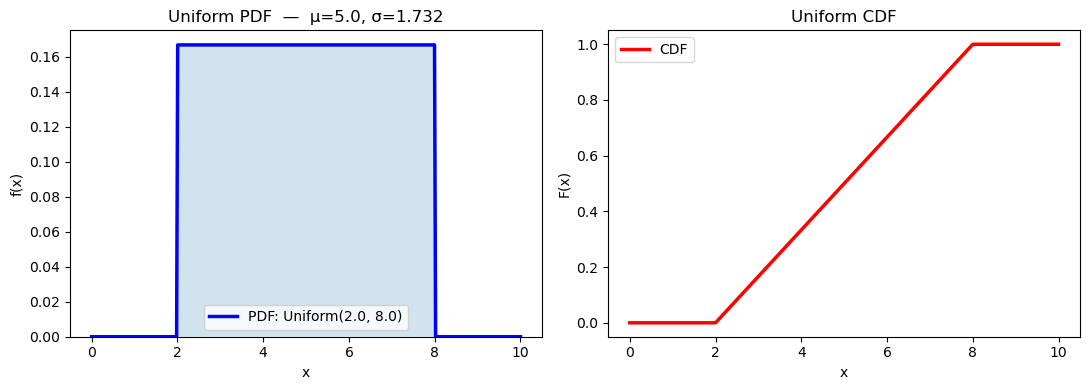

Theoretical  mean = 5.0000,  std = 1.7321
Sample       mean = 4.9935,  std = 1.7449  (n=2000)


In [10]:
# ── Uniform distribution ─────────────────────────────────────────────────────
rng = np.random.default_rng(seed=0)
a, b = 2.0, 8.0

# scipy.stats.uniform: loc=a, scale=(b-a)
dist_u = stats.uniform(loc=a, scale=b - a)

x = np.linspace(0, 10, 400)
samples = rng.uniform(a, b, 2000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# PDF + CDF
axes[0].plot(x, dist_u.pdf(x), 'b-', linewidth=2.5, label=f'PDF: Uniform({a}, {b})')
axes[0].fill_between(x, dist_u.pdf(x), alpha=0.2)
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].set_title(f'Uniform PDF  —  μ={dist_u.mean():.1f}, σ={dist_u.std():.3f}')
axes[0].legend(); axes[0].set_ylim(bottom=0)

axes[1].plot(x, dist_u.cdf(x), 'r-', linewidth=2.5, label='CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].set_title('Uniform CDF'); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Theoretical  mean = {dist_u.mean():.4f},  std = {dist_u.std():.4f}")
print(f"Sample       mean = {np.mean(samples):.4f},  std = {np.std(samples, ddof=1):.4f}  (n=2000)")

(13.4.2)=
### 13.4.2 Normal (Gaussian) Distribution

The most important distribution in statistics. Symmetric, bell-shaped, described by two parameters: mean $\mu$ and standard deviation $\sigma$.

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
$$

**The 68-95-99.7 rule (empirical rule):**

$$
P(\mu - \sigma < X < \mu + \sigma) \approx 68\%
\qquad
P(\mu - 2\sigma < X < \mu + 2\sigma) \approx 95\%
\qquad
P(\mu - 3\sigma < X < \mu + 3\sigma) \approx 99.7\%
$$

**Engineering use:** Measurement errors, process variability, and — by the Central Limit Theorem — sample means from any distribution. Temperature measurements, product concentrations, particle sizes, and catalyst activity all tend toward normality in practice.

The **standard normal** $Z \sim \mathcal{N}(0, 1)$ arises by standardizing: $Z = (X - \mu)/\sigma$.

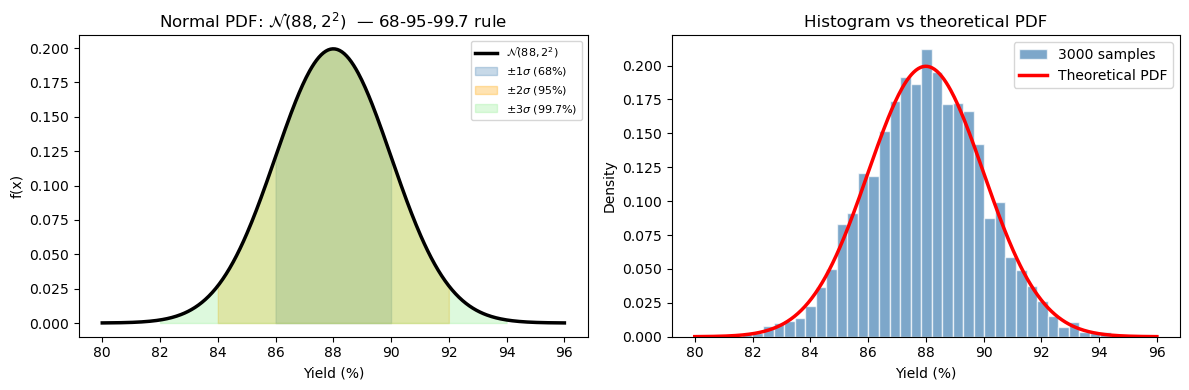

P(yield < 85%)  = 0.0668  (6.68% of batches fail lower limit)
P(yield > 92%)  = 0.0228  (2.28% of batches exceed upper limit)
P(85 ≤ yield ≤ 92%) = 0.9104


In [11]:
# ── Normal distribution ───────────────────────────────────────────────────────
rng  = np.random.default_rng(seed=1)
mu, sigma = 88.0, 2.0          # reactor yield: mean 88%, std 2%

dist_n = stats.norm(loc=mu, scale=sigma)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
samples_n = rng.normal(mu, sigma, 3000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── PDF with shaded regions ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(x, dist_n.pdf(x), 'k-', linewidth=2.5, label=r'$\mathcal{N}(88, 2^2)$')

# shade ±1σ, ±2σ, ±3σ regions
for k, color, label in [(1, 'steelblue', r'$\pm 1\sigma$ (68%)')  ,
                         (2, 'orange',    r'$\pm 2\sigma$ (95%)')  ,
                         (3, 'lightgreen',r'$\pm 3\sigma$ (99.7%)')]:
    x_fill = np.linspace(mu - k*sigma, mu + k*sigma, 200)
    ax.fill_between(x_fill, dist_n.pdf(x_fill), alpha=0.3, color=color, label=label)

ax.set_xlabel('Yield (%)')
ax.set_ylabel('f(x)')
ax.set_title(r'Normal PDF: $\mathcal{N}(88, 2^2)$  — 68-95-99.7 rule')
ax.legend(fontsize=8)

# ── Histogram of samples vs theoretical PDF ───────────────────────────────────
ax = axes[1]
ax.hist(samples_n, bins=40, density=True, color='steelblue',
        edgecolor='white', alpha=0.7, label='3000 samples')
ax.plot(x, dist_n.pdf(x), 'r-', linewidth=2.5, label='Theoretical PDF')
ax.set_xlabel('Yield (%)')
ax.set_ylabel('Density')
ax.set_title('Histogram vs theoretical PDF')
ax.legend()

plt.tight_layout()
plt.show()

# ── Key probabilities ─────────────────────────────────────────────────────────
p_below_85 = dist_n.cdf(85.0)
p_above_92 = 1 - dist_n.cdf(92.0)
print(f"P(yield < 85%)  = {p_below_85:.4f}  ({100*p_below_85:.2f}% of batches fail lower limit)")
print(f"P(yield > 92%)  = {p_above_92:.4f}  ({100*p_above_92:.2f}% of batches exceed upper limit)")
print(f"P(85 ≤ yield ≤ 92%) = {dist_n.cdf(92) - dist_n.cdf(85):.4f}")

### Using the CDF and Percent Point Function (PPF)

| Question | Tool | Formula |
|----------|------|--------|
| $P(X \leq x)$ | `.cdf(x)` | Direct lookup |
| $P(X > x)$ | `1 - .cdf(x)` | Survival function |
| Find $x$ such that $P(X \leq x) = p$ | `.ppf(p)` | Inverse CDF |

The **PPF** (percent point function, also called quantile function or inverse CDF) answers: "What value $x$ has $p \times 100\%$ of the distribution below it?"

In [12]:
# ── CDF / PPF examples ────────────────────────────────────────────────────────
print("Using the Normal distribution  N(88, 2)")
print()
print("CDF — P(X ≤ x):")
for x_val in [84, 86, 88, 90, 92]:
    print(f"  P(yield ≤ {x_val}%) = {dist_n.cdf(x_val):.4f}")

print()
print("PPF — what yield value corresponds to the p-th percentile:")
for p in [0.01, 0.05, 0.10, 0.25, 0.50, 0.90, 0.95, 0.99]:
    print(f"  {int(100*p):>3}th percentile → yield = {dist_n.ppf(p):.2f}%")

Using the Normal distribution  N(88, 2)

CDF — P(X ≤ x):
  P(yield ≤ 84%) = 0.0228
  P(yield ≤ 86%) = 0.1587
  P(yield ≤ 88%) = 0.5000
  P(yield ≤ 90%) = 0.8413
  P(yield ≤ 92%) = 0.9772

PPF — what yield value corresponds to the p-th percentile:
    1th percentile → yield = 83.35%
    5th percentile → yield = 84.71%
   10th percentile → yield = 85.44%
   25th percentile → yield = 86.65%
   50th percentile → yield = 88.00%
   90th percentile → yield = 90.56%
   95th percentile → yield = 91.29%
   99th percentile → yield = 92.65%


(13.4.3)=
### 13.4.3 Exponential Distribution

Describes the **time between independent random events** occurring at a constant average rate $\lambda$.

$$
f(x) = \lambda e^{-\lambda x}, \quad x \geq 0
\qquad
\mu = \frac{1}{\lambda}
\qquad
\sigma = \frac{1}{\lambda}
$$

NumPy/SciPy parameterize the exponential by **scale** $= 1/\lambda$ (the mean time between events).

**Engineering use:** Equipment failure times, time between catalyst poisoning events, inter-arrival times of molecules at a surface.

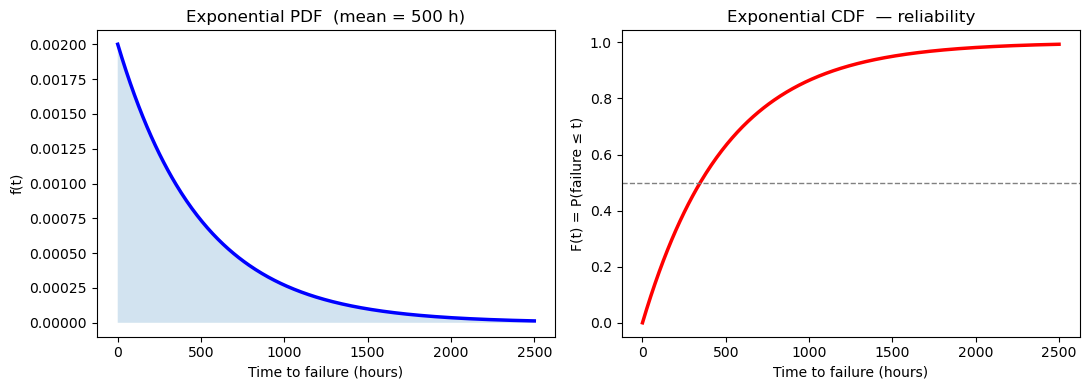

P(pump survives > 200 h) = 0.6703  (67.0%)
Median time to failure = 346.6 h  (50% chance of failure by this time)
Note: median = ln(2) × scale = 346.6 h


In [13]:
# ── Exponential distribution ──────────────────────────────────────────────────
# Example: a pump fails on average every 500 hours → scale = 500
scale = 500.0    # mean time between failures (hours)

dist_e = stats.expon(scale=scale)
x_e    = np.linspace(0, 2500, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x_e, dist_e.pdf(x_e), 'b-', linewidth=2.5)
axes[0].fill_between(x_e, dist_e.pdf(x_e), alpha=0.2)
axes[0].set_xlabel('Time to failure (hours)')
axes[0].set_ylabel('f(t)')
axes[0].set_title(f'Exponential PDF  (mean = {scale:.0f} h)')

axes[1].plot(x_e, dist_e.cdf(x_e), 'r-', linewidth=2.5)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Time to failure (hours)')
axes[1].set_ylabel('F(t) = P(failure ≤ t)')
axes[1].set_title('Exponential CDF  — reliability')

plt.tight_layout()
plt.show()

# Reliability questions
t_op = 200.0
p_survive = 1 - dist_e.cdf(t_op)
print(f"P(pump survives > {t_op:.0f} h) = {p_survive:.4f}  ({100*p_survive:.1f}%)")

t_50 = dist_e.ppf(0.50)
print(f"Median time to failure = {t_50:.1f} h  (50% chance of failure by this time)")
print(f"Note: median = ln(2) × scale = {np.log(2)*scale:.1f} h")

(13.4.4)=
### 13.4.4 Poisson Distribution

Counts the number of events in a fixed interval when events occur **independently at a constant average rate** $\lambda$.

$$
P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0, 1, 2, \ldots
\qquad
\mu = \lambda
\qquad
\sigma^2 = \lambda
$$

**Engineering use:** Number of particles deposited on a wafer per minute, number of catalyst pellet defects per batch, number of safety incidents per year.

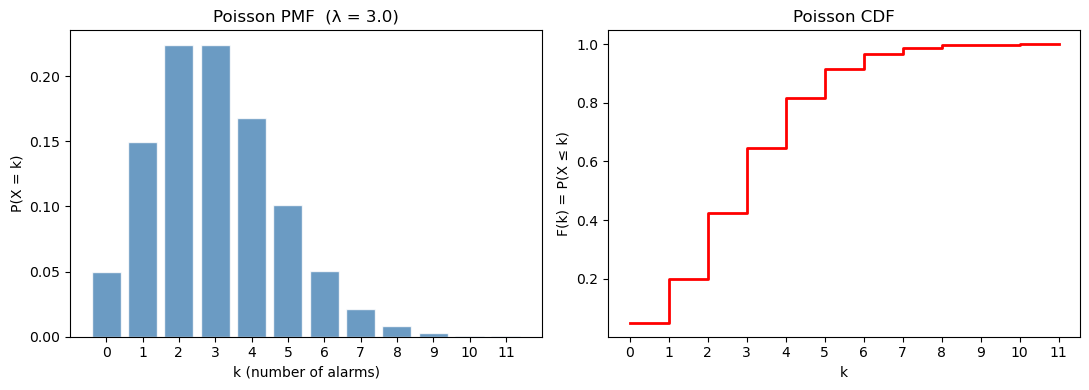

λ = 3.0  alarms per shift
P(0 alarms)         = 0.0498
P(≤ 5 alarms)       = 0.9161
P(> 6 alarms)       = 0.0335
Mean = 3.0,  Std = 1.7321,  Var = 3.0  (= λ)


In [14]:
# ── Poisson distribution ──────────────────────────────────────────────────────
# Example: on average 3 equipment alarms per 8-hour shift
lam = 3.0
k   = np.arange(0, 12)

dist_p = stats.poisson(mu=lam)
pmf    = dist_p.pmf(k)
cdf_p  = dist_p.cdf(k)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(k, pmf, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('k (number of alarms)')
axes[0].set_ylabel('P(X = k)')
axes[0].set_title(f'Poisson PMF  (λ = {lam})')
axes[0].set_xticks(k)

axes[1].step(k, cdf_p, where='post', color='red', linewidth=2)
axes[1].set_xlabel('k'); axes[1].set_ylabel('F(k) = P(X ≤ k)')
axes[1].set_title('Poisson CDF'); axes[1].set_xticks(k)

plt.tight_layout()
plt.show()

print(f"λ = {lam}  alarms per shift")
print(f"P(0 alarms)         = {dist_p.pmf(0):.4f}")
print(f"P(≤ 5 alarms)       = {dist_p.cdf(5):.4f}")
print(f"P(> 6 alarms)       = {1 - dist_p.cdf(6):.4f}")
print(f"Mean = {dist_p.mean():.1f},  Std = {dist_p.std():.4f},  Var = {dist_p.var():.1f}  (= λ)")

(13.4.5)=
### 13.4.5 Distribution Comparison

The four distributions have very different shapes. Choosing the right distribution for your data is one of the most important modeling decisions in statistics.

| Distribution | Support | Shape | Typical use |
|-------------|---------|-------|------------|
| **Uniform** | $[a, b]$ | Flat | Known bounds, no prior information |
| **Normal** | $(-\infty, \infty)$ | Symmetric bell | Measurement errors, process variations |
| **Exponential** | $[0, \infty)$ | Decaying | Time until failure, inter-arrival times |
| **Poisson** | $\{0, 1, 2, \ldots\}$ | Right-skewed (integer) | Count of rare events |

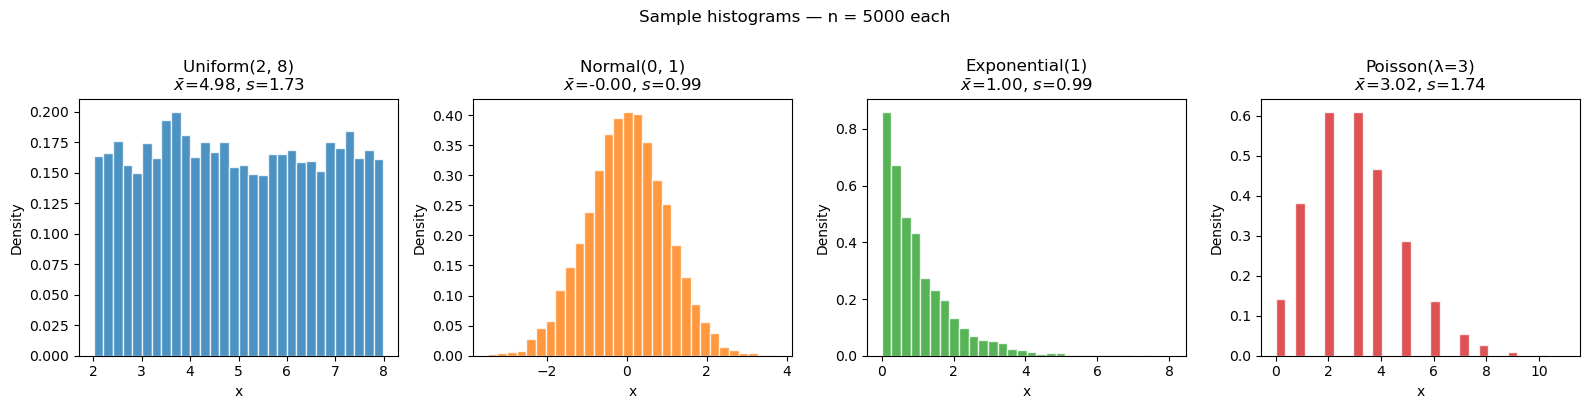

In [15]:
# ── Side-by-side summary of all four distributions ─────────────────────────────
rng = np.random.default_rng(seed=7)
n_samp = 5000

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
configs = [
    ('Uniform(2, 8)',   rng.uniform(2, 8, n_samp),        'tab:blue'  ),
    ('Normal(0, 1)',    rng.normal(0, 1, n_samp),          'tab:orange'),
    ('Exponential(1)',  rng.exponential(1.0, n_samp),      'tab:green' ),
    ('Poisson(λ=3)',    rng.poisson(3.0, n_samp).astype(float), 'tab:red'  ),
]

for ax, (title, data, color) in zip(axes, configs):
    ax.hist(data, bins=30, density=True, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.set_title(f'{title}\n$\\bar x$={np.mean(data):.2f}, $s$={np.std(data,ddof=1):.2f}')

plt.suptitle(f'Sample histograms — n = {n_samp} each', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

(13.5)=
## 13.5 Central Limit Theorem

The **Central Limit Theorem (CLT)** is arguably the most important result in statistics:

> **If you draw a sample of size $n$ from *any* distribution with finite mean $\mu$ and variance $\sigma^2$, the sample mean $\bar{X}$ is approximately normally distributed for large $n$:**
>
> $$\bar{X} \sim \mathcal{N}\!\left(\mu,\; \frac{\sigma^2}{n}\right) \qquad \text{as } n \to \infty$$

Equivalently:
$$
Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} \mathcal{N}(0, 1)
$$

**Why it matters in ChE:**
- The error on a measured mean shrinks as $1/\sqrt{n}$ — doubling precision requires 4× more measurements
- Justifies using normal-based confidence intervals even when individual measurements are not normal
- Underpins statistical process control (SPC) — control charts assume normality of sample means

The **standard error of the mean** is $\text{SE} = \sigma/\sqrt{n}$, the standard deviation of the *sample mean* distribution.

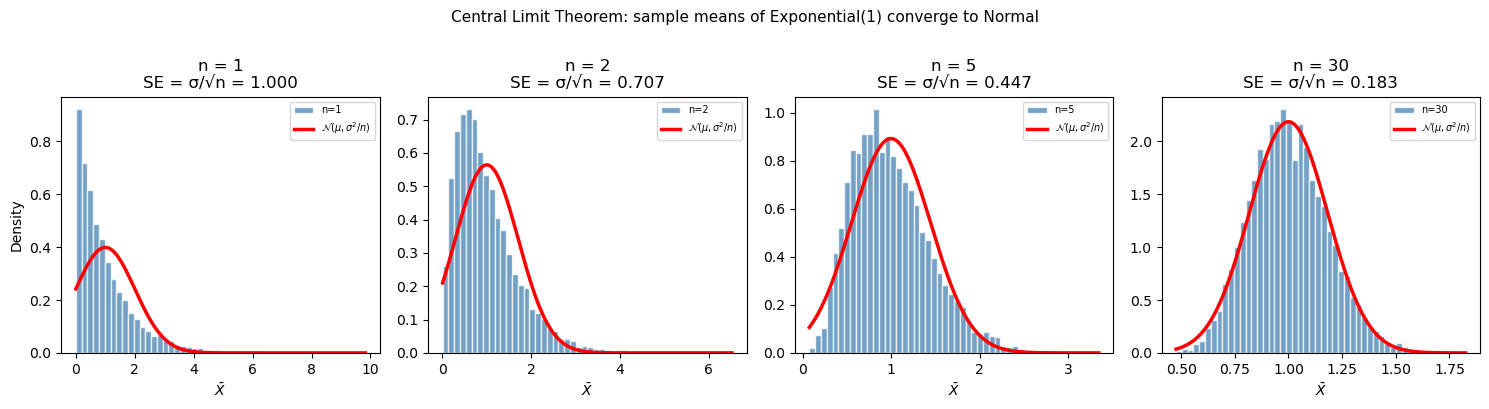

Sample size  |  SE_theory  |  SE_observed
---------------------------------------------
  n =   1     |  1.00000    |  0.99934
  n =   2     |  0.70711    |  0.71129
  n =   5     |  0.44721    |  0.45185
  n =  30     |  0.18257    |  0.18172


In [16]:
# ── Central Limit Theorem demonstration ──────────────────────────────────────
# Start from a very non-normal distribution: exponential(scale=1) → skewed
rng = np.random.default_rng(seed=99)

true_mu    = 1.0      # mean of Exp(1)
true_sigma = 1.0      # std  of Exp(1)
n_simulations = 10_000
sample_sizes  = [1, 2, 5, 30]

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(15, 4), sharey=False)

for ax, n in zip(axes, sample_sizes):
    # Draw n_simulations samples of size n; compute each sample mean
    data      = rng.exponential(true_mu, size=(n_simulations, n))
    means     = data.mean(axis=1)
    se        = true_sigma / np.sqrt(n)

    ax.hist(means, bins=50, density=True, color='steelblue',
            edgecolor='white', alpha=0.75, label=f'n={n}')

    # Overlay theoretical normal
    x_range = np.linspace(means.min(), means.max(), 200)
    ax.plot(x_range, stats.norm(true_mu, se).pdf(x_range),
            'r-', linewidth=2.5, label=r'$\mathcal{N}(\mu,\sigma^2/n)$')

    ax.set_title(f'n = {n}\nSE = σ/√n = {se:.3f}')
    ax.set_xlabel(r'$\bar{X}$')
    ax.set_ylabel('Density' if n == 1 else '')
    ax.legend(fontsize=7)

plt.suptitle('Central Limit Theorem: sample means of Exponential(1) converge to Normal',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("Sample size  |  SE_theory  |  SE_observed")
print("-" * 45)
for n in sample_sizes:
    data  = rng.exponential(true_mu, size=(n_simulations, n))
    means = data.mean(axis=1)
    print(f"  n = {n:>3}     |  {true_sigma/np.sqrt(n):.5f}    |  {np.std(means, ddof=1):.5f}")

(13.6)=
## 13.6 Confidence Intervals

A **confidence interval (CI)** is a range of values that is likely to contain the true population parameter. A 95% CI means: if we repeated the experiment many times and built a CI each time, 95% of those intervals would contain the true mean.

### CI for the mean — known σ (Z-interval)

If the population standard deviation $\sigma$ is known (or $n$ is large):

$$
\bar{x} \pm z_{\alpha/2} \frac{\sigma}{\sqrt{n}}
$$

where $z_{\alpha/2}$ is the z-score for significance level $\alpha$ (e.g., $z_{0.025} = 1.96$ for 95% CI).

### CI for the mean — unknown σ (t-interval)

With small samples and unknown $\sigma$, use the **Student's t-distribution** with $\nu = n - 1$ degrees of freedom:

$$
\bar{x} \pm t_{\alpha/2,\, n-1} \frac{s}{\sqrt{n}}
$$

The t-distribution has heavier tails than the normal — it accounts for additional uncertainty from estimating $\sigma$. As $n \to \infty$, the t-distribution converges to the standard normal.

| $n$ | $t_{0.025,\, n-1}$ (for 95% CI) |
|----|----------------------------------|
| 5  | 2.776 |
| 10 | 2.228 |
| 20 | 2.093 |
| 30 | 2.045 |
| ∞  | 1.960 (→ z) |

In [17]:
# ── Confidence interval for yield data ───────────────────────────────────────
n    = len(yields)
xbar = np.mean(yields)
s    = np.std(yields, ddof=1)
se   = s / np.sqrt(n)

print(f"Sample: n={n}, mean={xbar:.4f}%, s={s:.4f}%, SE={se:.4f}%")
print()

for conf in [0.90, 0.95, 0.99]:
    alpha = 1 - conf
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    margin = t_crit * se
    lo, hi = xbar - margin, xbar + margin
    print(f"{int(100*conf)}% CI:  [{lo:.4f}, {hi:.4f}]%   (t_crit = {t_crit:.3f}, margin = ±{margin:.4f})")

print()
# scipy convenience function — equivalent result
lo95, hi95 = stats.t.interval(0.95, df=n-1, loc=xbar, scale=se)
print(f"scipy.stats.t.interval(0.95): [{lo95:.4f}, {hi95:.4f}]%")

Sample: n=15, mean=87.7133%, s=1.8388%, SE=0.4748%

90% CI:  [86.8771, 88.5496]%   (t_crit = 1.761, margin = ±0.8362)
95% CI:  [86.6950, 88.7316]%   (t_crit = 2.145, margin = ±1.0183)
99% CI:  [86.3000, 89.1267]%   (t_crit = 2.977, margin = ±1.4133)

scipy.stats.t.interval(0.95): [86.6950, 88.7316]%


    n      Mean    95% CI width        SE
---------------------------------------------
    5   87.6727          4.8359    0.8709
   10   88.2080          2.8889    0.6385
   20   87.0618          1.3047    0.3117
   50   87.6672          1.0881    0.2707
  100   88.0120          0.7699    0.1940
  200   87.9284          0.5500    0.1395


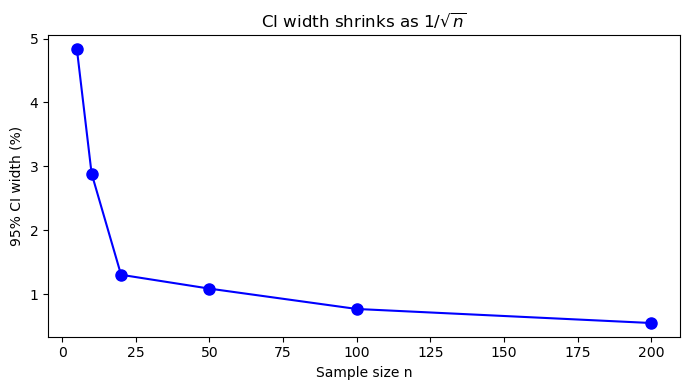

In [18]:
# ── How CI width shrinks with sample size ─────────────────────────────────────
rng   = np.random.default_rng(seed=5)
true_mu, true_sigma = 88.0, 2.0

ns     = [5, 10, 20, 50, 100, 200]
widths = []

print(f"{'n':>5}  {'Mean':>8}  {'95% CI width':>14}  {'SE':>8}")
print("-" * 45)
for n_val in ns:
    sample = rng.normal(true_mu, true_sigma, n_val)
    xb = np.mean(sample)
    se = np.std(sample, ddof=1) / np.sqrt(n_val)
    t  = stats.t.ppf(0.975, df=n_val-1)
    width = 2 * t * se
    widths.append(width)
    print(f"{n_val:>5}  {xb:>8.4f}  {width:>14.4f}  {se:>8.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, widths, 'bo-', markersize=8)
ax.set_xlabel('Sample size n')
ax.set_ylabel('95% CI width (%)')
ax.set_title('CI width shrinks as $1/\\sqrt{n}$')
plt.tight_layout()
plt.show()

(13.7)=
## 13.7 Monte Carlo Simulation

**Monte Carlo simulation** uses random sampling to estimate quantities that are difficult or impossible to compute analytically. The core idea:

1. Model each uncertain input as a probability distribution
2. Draw thousands of random samples from those distributions
3. Compute the output for each sample
4. Analyze the distribution of outputs

This is especially powerful for **uncertainty propagation** — if your inputs have uncertainty, how large is the uncertainty in your output?

Analytical error propagation (first-order) says:
$$
\sigma_f^2 \approx \sum_i \left(\frac{\partial f}{\partial x_i}\right)^2 \sigma_{x_i}^2
$$

Monte Carlo is more general — it works for **nonlinear functions** and **any distribution**, not just normal.

(13.7.1)=
### 13.7.1 Error Propagation: Arrhenius Rate Constant

The Arrhenius rate constant:
$$k = A \exp\!\left(-\frac{E_a}{RT}\right)$$

If both $E_a$ and $T$ have measurement uncertainty, what is the uncertainty in $k$?

**Given:**
- $A = 1 \times 10^8$ s$^{-1}$ (exact)
- $E_a = 75{,}000 \pm 1{,}000$ J/mol — measured activation energy, normally distributed with $\sigma = 500$ J/mol
- $T = 500 \pm 3$ K — temperature measurement, normally distributed with $\sigma = 1.5$ K
- $R = 8.314$ J/(mol K)

Nominal k at (Ea=75000 J/mol, T=500 K):
  k_nominal = 1.460565 s⁻¹

Monte Carlo results (N = 100,000):
  k mean  = 1.474138 s⁻¹
  k std   = 0.195817 s⁻¹
  k CV    = 13.28%  (coefficient of variation)
  k 2.5th percentile  = 1.125242 s⁻¹
  k 97.5th percentile = 1.893896 s⁻¹


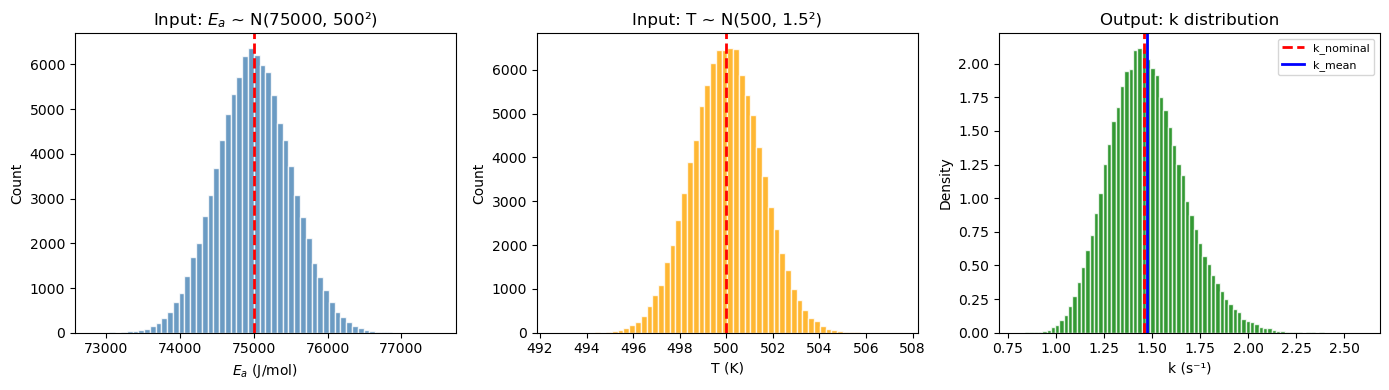

In [19]:
# ── Monte Carlo error propagation: Arrhenius rate constant ────────────────────
rng    = np.random.default_rng(seed=42)
N_mc   = 100_000
R      = 8.314
A_pre  = 1e8

# Input distributions
Ea_mu, Ea_sig = 75_000.0, 500.0    # J/mol
T_mu,  T_sig  = 500.0,    1.5      # K

Ea_samples = rng.normal(Ea_mu, Ea_sig, N_mc)
T_samples  = rng.normal(T_mu,  T_sig,  N_mc)

# Output: k for each sample
k_samples = A_pre * np.exp(-Ea_samples / (R * T_samples))

# Deterministic value at nominal inputs
k_nominal = A_pre * np.exp(-Ea_mu / (R * T_mu))

print(f"Nominal k at (Ea={Ea_mu:.0f} J/mol, T={T_mu:.0f} K):")
print(f"  k_nominal = {k_nominal:.6f} s⁻¹")
print()
print(f"Monte Carlo results (N = {N_mc:,}):")
print(f"  k mean  = {np.mean(k_samples):.6f} s⁻¹")
print(f"  k std   = {np.std(k_samples, ddof=1):.6f} s⁻¹")
print(f"  k CV    = {100*np.std(k_samples)/np.mean(k_samples):.2f}%  (coefficient of variation)")
print(f"  k 2.5th percentile  = {np.percentile(k_samples,  2.5):.6f} s⁻¹")
print(f"  k 97.5th percentile = {np.percentile(k_samples, 97.5):.6f} s⁻¹")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(Ea_samples, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(Ea_mu, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('$E_a$ (J/mol)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Input: $E_a$ ~ N({Ea_mu:.0f}, {Ea_sig:.0f}²)')

axes[1].hist(T_samples, bins=60, color='orange', edgecolor='white', alpha=0.8)
axes[1].axvline(T_mu, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('T (K)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Input: T ~ N({T_mu:.0f}, {T_sig:.1f}²)')

axes[2].hist(k_samples, bins=80, color='green', edgecolor='white', alpha=0.8, density=True)
axes[2].axvline(k_nominal, color='red', linestyle='--', linewidth=2, label='k_nominal')
axes[2].axvline(np.mean(k_samples), color='blue', linestyle='-', linewidth=2, label='k_mean')
axes[2].set_xlabel('k (s⁻¹)'); axes[2].set_ylabel('Density')
axes[2].set_title('Output: k distribution'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

(13.7.2)=
### 13.7.2 Process Reliability: Fraction of Batches Meeting Spec

A chemical product must have purity $\geq 97.5\%$ to be sold. Purity depends on two input variables:

$$
\text{Purity} = 100 \times \left(1 - 0.04\,e^{-k(T)\,\tau} \right)
$$

where:
- $k(T) = 0.1 \exp\!\left(-\frac{5000}{T}\right)$ is a simplified rate constant (s$^{-1}$)
- $\tau$ (residence time, s) ~ Normal(120, 10²)
- $T$ (temperature, K) ~ Normal(400, 5²)

What fraction of batches will fail the spec?

Monte Carlo reliability analysis  (N = 200,000)
  Purity mean  = 96.000%
  Purity std   = 0.000%
  Purity 5th percentile  = 96.000%
  Spec limit             = 97.5%
  Fraction BELOW spec    = 1.0000  (100.00% failure rate)
  Fraction ABOVE spec    = 0.0000  (0.00% pass rate)


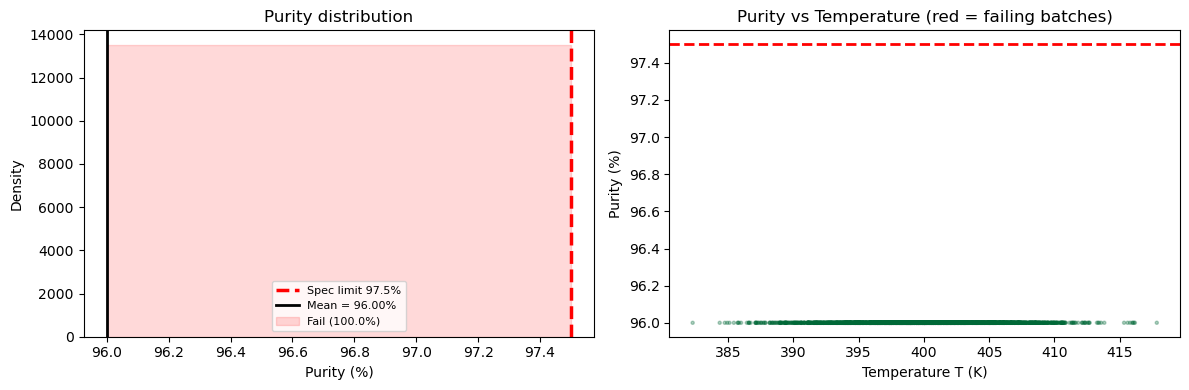

In [20]:
# ── Monte Carlo process reliability ───────────────────────────────────────────
rng   = np.random.default_rng(seed=17)
N_mc  = 200_000

# Uncertain inputs
tau_samples = rng.normal(120.0, 10.0,  N_mc)    # residence time (s)
T_samples2  = rng.normal(400.0,  5.0,  N_mc)    # temperature (K)

# Simplified rate constant and purity model
k_samples2  = 0.1 * np.exp(-5000.0 / T_samples2)
purity      = 100.0 * (1.0 - 0.04 * np.exp(-k_samples2 * tau_samples))

spec_limit  = 97.5   # %
frac_fail   = np.mean(purity < spec_limit)
frac_pass   = 1.0 - frac_fail

print(f"Monte Carlo reliability analysis  (N = {N_mc:,})")
print(f"  Purity mean  = {np.mean(purity):.3f}%")
print(f"  Purity std   = {np.std(purity, ddof=1):.3f}%")
print(f"  Purity 5th percentile  = {np.percentile(purity, 5):.3f}%")
print(f"  Spec limit             = {spec_limit}%")
print(f"  Fraction BELOW spec    = {frac_fail:.4f}  ({100*frac_fail:.2f}% failure rate)")
print(f"  Fraction ABOVE spec    = {frac_pass:.4f}  ({100*frac_pass:.2f}% pass rate)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(purity, bins=80, density=True, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(spec_limit, color='red', linestyle='--', linewidth=2.5, label=f'Spec limit {spec_limit}%')
ax.axvline(np.mean(purity), color='black', linestyle='-', linewidth=2, label=f'Mean = {np.mean(purity):.2f}%')
# shade the failing region
ax.fill_between([purity.min(), spec_limit],
                0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
                alpha=0.15, color='red', label=f'Fail ({100*frac_fail:.1f}%)')
ax.set_xlabel('Purity (%)')
ax.set_ylabel('Density')
ax.set_title('Purity distribution')
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(T_samples2[:3000], purity[:3000],
           c=(purity[:3000] < spec_limit), cmap='RdYlGn_r',
           alpha=0.3, s=5)
ax.axhline(spec_limit, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Temperature T (K)')
ax.set_ylabel('Purity (%)')
ax.set_title('Purity vs Temperature (red = failing batches)')

plt.tight_layout()
plt.show()

(13.7.3)=
### 13.7.3 Classic Monte Carlo: Estimating π

A famous demonstration: estimate $\pi$ by randomly throwing darts at a unit square.

A quarter-circle of radius 1 has area $\pi/4$. If darts are thrown uniformly over the $[0,1]^2$ square, the fraction landing inside the quarter-circle is $\pi/4$:

$$
\hat{\pi} = 4 \times \frac{\text{number of darts inside circle}}{\text{total darts}}
$$

The error shrinks as $\sim 1/\sqrt{N}$ — a classic illustration of Monte Carlo convergence.

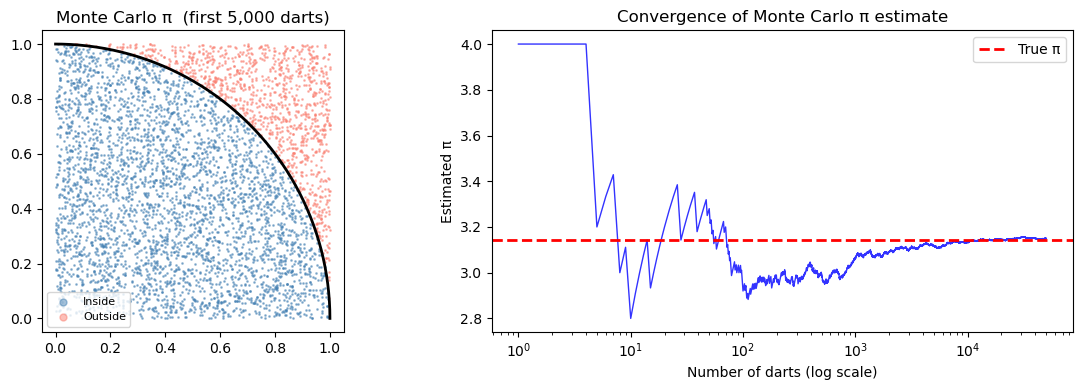

True π               = 3.14159265
MC estimate (N=50,000) = 3.14968000
Error                = 8.09e-03


In [21]:
# ── Monte Carlo estimate of π ─────────────────────────────────────────────────
rng    = np.random.default_rng(seed=0)
N_darts = 50_000

x_darts = rng.random(N_darts)
y_darts = rng.random(N_darts)
inside  = (x_darts**2 + y_darts**2) <= 1.0

# Running estimate as we add more darts
N_run    = np.arange(1, N_darts + 1)
pi_est   = 4.0 * np.cumsum(inside) / N_run

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Dart scatter plot (show first 5000)
ax = axes[0]
n_show = 5000
ax.scatter(x_darts[:n_show][inside[:n_show]],  y_darts[:n_show][inside[:n_show]],
           s=1, color='steelblue', alpha=0.5, label='Inside')
ax.scatter(x_darts[:n_show][~inside[:n_show]], y_darts[:n_show][~inside[:n_show]],
           s=1, color='salmon',    alpha=0.5, label='Outside')
theta = np.linspace(0, np.pi/2, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)
ax.set_aspect('equal')
ax.set_title(f'Monte Carlo π  (first {n_show:,} darts)')
ax.legend(fontsize=8, markerscale=5)

# Convergence
ax = axes[1]
ax.semilogx(N_run, pi_est, 'b-', linewidth=1, alpha=0.8)
ax.axhline(np.pi, color='red', linestyle='--', linewidth=2, label='True π')
ax.set_xlabel('Number of darts (log scale)')
ax.set_ylabel('Estimated π')
ax.set_title('Convergence of Monte Carlo π estimate')
ax.legend()

plt.tight_layout()
plt.show()

print(f"True π               = {np.pi:.8f}")
print(f"MC estimate (N={N_darts:,}) = {pi_est[-1]:.8f}")
print(f"Error                = {abs(pi_est[-1] - np.pi):.2e}")

(13.8)=
## 13.8 Fitting Distributions to Data

Given a dataset, we often want to identify which probability distribution best describes it. `scipy.stats` provides `.fit()` methods that estimate the parameters of a distribution from data using maximum likelihood estimation (MLE).

Once fit, the **Q-Q plot** (quantile-quantile plot) is the standard visual tool to assess goodness of fit: if the data follows the assumed distribution, the Q-Q plot will be approximately a straight line.

Fitted Normal: μ = 87.7133%, σ = 1.7765%
(Compare: sample mean = 87.7133%, sample std = 1.8388%)


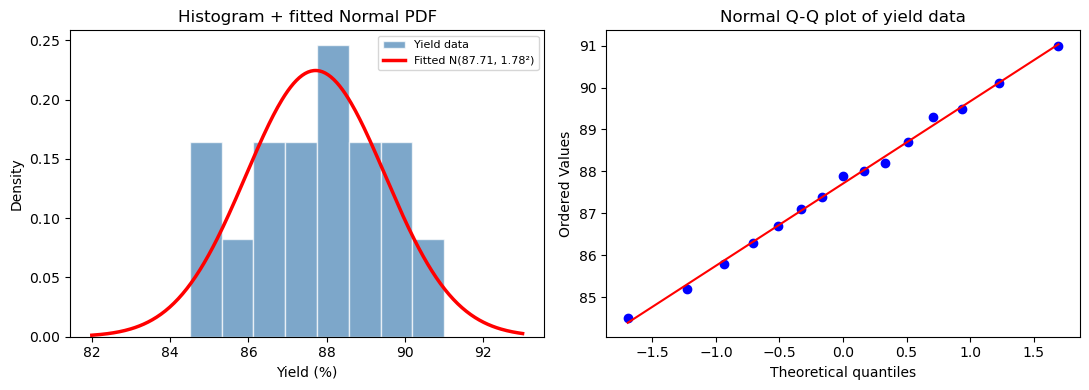


Kolmogorov-Smirnov test vs fitted Normal:
  KS statistic = 0.0808
  p-value      = 0.9998
  Conclusion   : Cannot reject Normal fit (p > 0.05)


In [22]:
# ── Fit a normal distribution to the yield data ───────────────────────────────
mu_fit, sigma_fit = stats.norm.fit(yields)
print(f"Fitted Normal: μ = {mu_fit:.4f}%, σ = {sigma_fit:.4f}%")
print(f"(Compare: sample mean = {np.mean(yields):.4f}%, sample std = {np.std(yields, ddof=1):.4f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram + fitted PDF
ax = axes[0]
x_fit = np.linspace(82, 93, 300)
ax.hist(yields, bins=8, density=True, color='steelblue',
        edgecolor='white', alpha=0.7, label='Yield data')
ax.plot(x_fit, stats.norm.pdf(x_fit, mu_fit, sigma_fit),
        'r-', linewidth=2.5, label=f'Fitted N({mu_fit:.2f}, {sigma_fit:.2f}²)')
ax.set_xlabel('Yield (%)'); ax.set_ylabel('Density')
ax.set_title('Histogram + fitted Normal PDF')
ax.legend(fontsize=8)

# Q-Q plot
ax = axes[1]
stats.probplot(yields, dist='norm', plot=ax)
ax.set_title('Normal Q-Q plot of yield data')

plt.tight_layout()
plt.show()

# Kolmogorov-Smirnov test: does the data follow the fitted normal?
ks_stat, ks_p = stats.kstest(yields, 'norm', args=(mu_fit, sigma_fit))
print(f"\nKolmogorov-Smirnov test vs fitted Normal:")
print(f"  KS statistic = {ks_stat:.4f}")
print(f"  p-value      = {ks_p:.4f}")
print(f"  Conclusion   : {'Cannot reject Normal fit (p > 0.05)' if ks_p > 0.05 else 'Reject Normal fit (p < 0.05)'}")

(13.9)=
## 13.9 Hypothesis Testing

A **hypothesis test** asks: is a specific claim about the data supported by the evidence?

### Framework

1. **Null hypothesis $H_0$:** The default assumption (e.g., "the mean yield equals the target of 88%")
2. **Alternative hypothesis $H_1$:** What we're trying to show (e.g., "the mean yield differs from 88%")
3. **Test statistic:** A number computed from the data that measures how far the data is from $H_0$
4. **p-value:** The probability of observing results at least as extreme as the data, *assuming $H_0$ is true*
5. **Decision:** Reject $H_0$ if p-value $< \alpha$ (significance level, typically $\alpha = 0.05$)

### One-sample t-test

Tests whether the sample mean equals a specified value $\mu_0$:

$$
H_0: \mu = \mu_0 \qquad H_1: \mu \neq \mu_0
\qquad
t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}
$$

Under $H_0$, $t$ follows a $t$-distribution with $n-1$ degrees of freedom.

In [23]:
# ── One-sample t-test: is the mean yield equal to 88%? ────────────────────────
mu_0 = 88.0    # target yield (%)

t_stat, p_val = stats.ttest_1samp(yields, popmean=mu_0)

n    = len(yields)
xbar = np.mean(yields)
s    = np.std(yields, ddof=1)
se   = s / np.sqrt(n)

print("One-sample t-test: H₀: μ = 88.0%  vs  H₁: μ ≠ 88.0%")
print(f"  n            = {n}")
print(f"  x̄            = {xbar:.4f}%")
print(f"  s            = {s:.4f}%")
print(f"  SE           = {se:.4f}%")
print(f"  t-statistic  = {t_stat:.4f}")
print(f"  p-value      = {p_val:.4f}")
print()
alpha = 0.05
if p_val < alpha:
    print(f"  p = {p_val:.4f} < α = {alpha}: Reject H₀ — evidence that mean ≠ 88%")
else:
    print(f"  p = {p_val:.4f} > α = {alpha}: Fail to reject H₀ — no evidence mean differs from 88%")

One-sample t-test: H₀: μ = 88.0%  vs  H₁: μ ≠ 88.0%
  n            = 15
  x̄            = 87.7133%
  s            = 1.8388%
  SE           = 0.4748%
  t-statistic  = -0.6038
  p-value      = 0.5556

  p = 0.5556 > α = 0.05: Fail to reject H₀ — no evidence mean differs from 88%


Two-sample t-test: H₀: μ_new = μ_old  vs  H₁: μ_new > μ_old
  Old catalyst:  n=10, mean=86.560%, s=1.267%
  New catalyst:  n=12, mean=89.625%, s=0.908%
  Difference:    Δμ = 3.065%
  t-statistic  = 6.4029
  p-value (two-sided) = 0.0000
  p-value (one-sided: new > old) = 0.0000

  Conclusion: The new catalyst significantly improves yield (p < 0.05, one-sided).


/var/folders/0w/xt4lf1l923l353q32j8pqq000000gn/T/ipykernel_25755/4174327195.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([yields_old, yields_new], labels=['Old catalyst', 'New catalyst'],


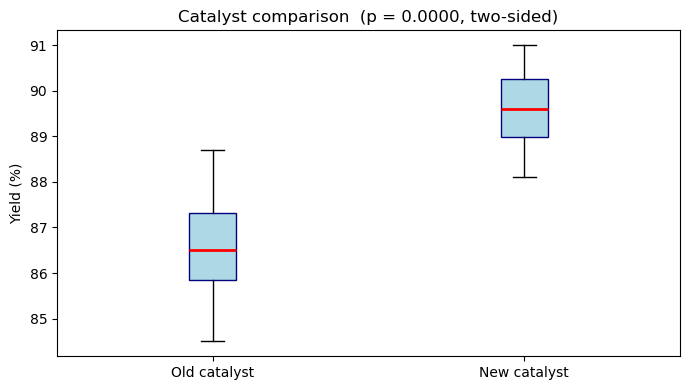

In [24]:
# ── Two-sample t-test: did changing the catalyst improve yield? ───────────────
# Old catalyst: 10 batches
yields_old = np.array([85.2, 87.9, 86.3, 88.7, 84.5, 87.1, 85.8, 86.7, 87.4, 86.0])
# New catalyst: 12 batches
yields_new = np.array([88.1, 89.5, 90.2, 88.9, 91.0, 89.3, 90.8, 89.0, 88.5, 90.1, 89.7, 90.4])

t2, p2 = stats.ttest_ind(yields_new, yields_old, equal_var=False)  # Welch's t-test

print("Two-sample t-test: H₀: μ_new = μ_old  vs  H₁: μ_new > μ_old")
print(f"  Old catalyst:  n={len(yields_old)}, mean={np.mean(yields_old):.3f}%, s={np.std(yields_old,ddof=1):.3f}%")
print(f"  New catalyst:  n={len(yields_new)}, mean={np.mean(yields_new):.3f}%, s={np.std(yields_new,ddof=1):.3f}%")
print(f"  Difference:    Δμ = {np.mean(yields_new) - np.mean(yields_old):.3f}%")
print(f"  t-statistic  = {t2:.4f}")
print(f"  p-value (two-sided) = {p2:.4f}")
print(f"  p-value (one-sided: new > old) = {p2/2:.4f}")
print()
if p2/2 < 0.05:
    print("  Conclusion: The new catalyst significantly improves yield (p < 0.05, one-sided).")
else:
    print("  Conclusion: No significant difference detected at α = 0.05.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([yields_old, yields_new], labels=['Old catalyst', 'New catalyst'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Yield (%)')
ax.set_title(f'Catalyst comparison  (p = {p2:.4f}, two-sided)')
plt.tight_layout()
plt.show()

(13.10)=
## 13.10 Summary

| Concept | Tool / Formula | When to use |
|---------|---------------|-------------|
| **Sample mean** | `np.mean(x)` | Center of data |
| **Sample std dev** | `np.std(x, ddof=1)` | Spread of data (always `ddof=1` for samples) |
| **Percentile** | `np.percentile(x, q)` | Quantify tails, IQR |
| **Descriptive summary** | `scipy.stats.describe(x)` | Quick overview incl. skewness, kurtosis |
| **Random generation** | `rng = np.random.default_rng(seed)` | Reproducible random sampling |
| **Normal distribution** | `stats.norm(mu, sigma)` | Measurement errors, process variability |
| **Uniform distribution** | `stats.uniform(loc, scale)` | Bounded uncertainty, no preference |
| **Exponential distribution** | `stats.expon(scale=1/λ)` | Time to failure, waiting times |
| **Poisson distribution** | `stats.poisson(mu=λ)` | Counts of rare events |
| **CDF / PPF** | `.cdf(x)` / `.ppf(p)` | Probability below $x$ / value at $p$-th percentile |
| **Central Limit Theorem** | $\bar{X} \sim \mathcal{N}(\mu, \sigma^2/n)$ | Justifies normality of sample means |
| **Confidence interval** | `stats.t.interval(conf, df, loc, scale)` | Range for the true mean |
| **Monte Carlo** | Sample inputs → compute outputs → analyze | Uncertainty propagation, reliability |
| **Distribution fitting** | `stats.norm.fit(data)` | Parameter estimation from data |
| **Q-Q plot** | `stats.probplot(data, plot=ax)` | Visual goodness-of-fit check |
| **One-sample t-test** | `stats.ttest_1samp(x, mu0)` | Does mean equal a target? |
| **Two-sample t-test** | `stats.ttest_ind(x1, x2)` | Are two group means different? |

**Key rules of thumb for ChE:**
- Always use `ddof=1` when computing variance or std dev from experimental data
- Use the **t-distribution** (not normal) for small samples ($n < 30$) and unknown $\sigma$
- The standard error of the mean shrinks as $1/\sqrt{n}$ — doubling precision costs 4× measurements
- **Monte Carlo** is the most general tool for uncertainty propagation — use it when analytical formulas are messy or unavailable
- A p-value $< 0.05$ means "surprising under $H_0$", not "the effect is large" — always report the actual effect size alongside the p-value